## Function 2 — Week 9: SFGP with qLogNEI + Exploration Recovery (Continued)

This notebook processes the **Week 9** updated data for Function 2 and proposes the next sample point.

**Strategy (carried from Week 8)**: The Week 8 strategy of 15-restart MLL with bounded lengthscales and q=4 distance-based selection successfully recovered exploration after Week 7's degenerate GP. We continue the same approach for Week 9.

**Enhancements in Week 9**:
- **Three-colour visualisation**: Initial samples (blue), weekly submissions (orange), proposed next point (green star)
- **Performance evaluation**: Convergence metrics, exploration spread analysis, LOO surrogate error, and strategy interpretation

- **Surrogate**: SFGP Matérn-1.5, ARD, noise_lb=1e-3, lengthscale bounded [0.01, 2.0]
- **Acquisition**: qLogNEI (q=4) → distance-based selection (mean ≥ median, farthest from data)
- **Data**: 19 cumulative samples (10 initial + 9 weekly)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import copy
import warnings
from scipy.spatial.distance import pdist, squareform

from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan, Interval
from gpytorch.mlls import ExactMarginalLogLikelihood

warnings.filterwarnings('ignore', message='The input matches the stored training data')
warnings.filterwarnings('ignore', category=RuntimeWarning)
print("All imports successful.")

All imports successful.


### Strategy Recap (Carried from Week 8)

The Week 8 strategy addressed Week 7's degenerate GP (x2 lengthscale collapsed to ~5000) with three fixes that are continued unchanged:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| **MLL restarts** | 15 | Avoids degenerate local optima in MLL landscape |
| **Lengthscale bounds** | [0.01, 2.0] | Prevents x2 lengthscale from collapsing to infinity |
| **q (batch size)** | 4 | Generates diverse candidates for distance-based selection |
| **Selection** | Distance-based | Filter to mean ≥ median, pick farthest from data |

No strategy changes are made for Week 9. The performance evaluation section at the end of this notebook will assess whether changes are warranted for Week 10.

In [2]:
# ─── Data Shape ────────────────────────────────────────────────────────────────
N_INITIAL   = 10          # Initial samples
N_TOTAL     = 19          # Total samples through Week 9 (10 + 9 weekly)
N_DIMS      = 2           # Input dimensionality
N_SUBMISSIONS = N_TOTAL - N_INITIAL  # 9 weekly submissions

# ─── SFGP Kernel & Noise ──────────────────────────────────────────────────────
KERNEL          = 'matern15'
NOISE_LB        = 1e-3
ARD             = True
INPUT_NORM      = True
LS_LOWER        = 0.01    # Lengthscale lower bound
LS_UPPER        = 2.0     # Lengthscale upper bound — prevents x2 collapsing to infinity
LS_INIT         = 0.5     # Initial lengthscale for all dimensions
NOISE_INIT      = 0.01    # Initial noise (moderate)
OUTPUTSCALE_INIT = 1.0    # Initial output scale

# ─── Multi-restart MLL ────────────────────────────────────────────────────────
N_MLL_RESTARTS = 15       # Guards against degenerate local optima in MLL

# ─── Acquisition Optimisation ─────────────────────────────────────────────────
Q           = 4           # Batch size — diverse candidates for distance-based selection
MC_SAMPLES  = 512         # Sobol quasi-MC samples for qLogNEI
N_RESTARTS  = 20          # Multi-start restarts for batch acquisition
RAW_SAMPLES = 1024        # Sobol initial candidates
BOUNDS = torch.tensor([[0.0, 0.0],
                        [1.0, 1.0]], dtype=torch.float64)

# ─── Performance Evaluation Constants ─────────────────────────────────────────
STALLING_CONSECUTIVE_THRESHOLD = 3    # Trailing no-improvement streak to flag stalling
STALLING_RELATIVE_THRESHOLD    = 0.05 # Relative improvement below this → stalling

print("Week 9 Hyperparameters:")
print(f"  N_INITIAL:     {N_INITIAL}")
print(f"  N_TOTAL:       {N_TOTAL}")
print(f"  N_SUBMISSIONS: {N_SUBMISSIONS}")
print(f"  N_DIMS:        {N_DIMS}")
print(f"  Kernel:        {KERNEL}")
print(f"  Noise LB:      {NOISE_LB}")
print(f"  LS bounds:     [{LS_LOWER}, {LS_UPPER}]")
print(f"  LS init:       {LS_INIT}")
print(f"  MLL restarts:  {N_MLL_RESTARTS}")
print(f"  Q (batch):     {Q}")
print(f"  MC samples:    {MC_SAMPLES}")
print(f"  Acq restarts:  {N_RESTARTS}")
print(f"  Raw samples:   {RAW_SAMPLES}")
print(f"  Stalling threshold (consecutive): {STALLING_CONSECUTIVE_THRESHOLD}")
print(f"  Stalling threshold (relative):    {STALLING_RELATIVE_THRESHOLD}")

Week 9 Hyperparameters:
  N_INITIAL:     10
  N_TOTAL:       19
  N_SUBMISSIONS: 9
  N_DIMS:        2
  Kernel:        matern15
  Noise LB:      0.001
  LS bounds:     [0.01, 2.0]
  LS init:       0.5
  MLL restarts:  15
  Q (batch):     4
  MC samples:    512
  Acq restarts:  20
  Raw samples:   1024
  Stalling threshold (consecutive): 3
  Stalling threshold (relative):    0.05


### Step 3: Load Week 9 Data

Load the cumulative Week 9 data (19 total samples = initial 10 + 9 weekly submissions). Split into initial and submission subsets for performance evaluation and visualisation.

In [3]:
# Load Week 9 cumulative data
X = np.load('../../data/f2/updated_inputs - Week 9.npy')
y = np.load('../../data/f2/updated_outputs - Week 9.npy')

# Validate dimensions and ranges
assert X.shape == (N_TOTAL, N_DIMS), f"Expected ({N_TOTAL}, {N_DIMS}), got {X.shape}"
assert y.shape == (N_TOTAL,), f"Expected ({N_TOTAL},), got {y.shape}"
assert np.all((X >= 0.0) & (X <= 1.0)), "Inputs out of [0, 1] range"
assert not np.any(np.isnan(y)), "Outputs contain NaN"

# Split into initial samples and weekly submissions
X_initial = X[:N_INITIAL]
y_initial = y[:N_INITIAL]
X_submissions = X[N_INITIAL:]
y_submissions = y[N_INITIAL:]

assert X_submissions.shape[0] == N_SUBMISSIONS, (
    f"Expected {N_SUBMISSIONS} submissions, got {X_submissions.shape[0]}"
)

print(f"Week 9 Data: {X.shape[0]} samples, {X.shape[1]} dimensions")
print(f"  Initial samples:    {len(y_initial)}")
print(f"  Weekly submissions: {len(y_submissions)}")
print(f"Input range:  [{X.min():.6f}, {X.max():.6f}]")
print(f"Output range: [{y.min():.6f}, {y.max():.6f}]")
print(f"Best observed value: {y.max():.6f} at index {y.argmax()}")
print(f"Best observed point: {X[y.argmax()]}")

# Display tabular data
print(f"\n{'Idx':>4}  {'Type':>8}  {'x1':>10}  {'x2':>10}  {'y':>12}")
print("-" * 52)
for i in range(len(y)):
    marker = " ← best" if i == y.argmax() else ""
    src = "initial" if i < N_INITIAL else f"wk{i - N_INITIAL + 1}"
    print(f"{i:>4}  {src:>8}  {X[i,0]:>10.6f}  {X[i,1]:>10.6f}  {y[i]:>12.6f}{marker}")

Week 9 Data: 19 samples, 2 dimensions
  Initial samples:    10
  Weekly submissions: 9
Input range:  [0.019944, 1.000000]
Output range: [-0.065624, 0.674355]
Best observed value: 0.674355 at index 10
Best observed point: [0.693877 0.673469]

 Idx      Type          x1          x2             y
----------------------------------------------------
   0   initial    0.665800    0.123969      0.538996
   1   initial    0.877791    0.778628      0.420586
   2   initial    0.142699    0.349005     -0.065624
   3   initial    0.845275    0.711120      0.293993
   4   initial    0.454647    0.290455      0.214965
   5   initial    0.577713    0.771973      0.023106
   6   initial    0.438166    0.685018      0.244619
   7   initial    0.341750    0.028698      0.038749
   8   initial    0.338648    0.213867     -0.013858
   9   initial    0.702637    0.926564      0.611205
  10       wk1    0.693877    0.673469      0.674355 ← best
  11       wk2    0.965009    0.754037      0.054376
  12     

### Step 4: Train SFGP Model (15-Restart MLL with Lengthscale Bounds)

Fit the SFGP on all 19 Week 9 samples using a **15-restart** MLL procedure:
- Each restart uses a different `torch.manual_seed` and re-initialises lengthscales to 0.5
- Lengthscales are bounded to **[0.01, 2.0]** via `Interval` constraint — prevents degenerate solutions
- Best model is selected by lowest negative MLL, then preserved via `copy.deepcopy`

In [4]:
# Prepare tensors
X_train_t = torch.tensor(X, dtype=torch.float64)                # shape: [19, 2]
y_train_t = torch.tensor(y, dtype=torch.float64).unsqueeze(-1)  # shape: [19, 1]

# 15-restart MLL fitting with lengthscale bounds
best_loss = float('inf')
best_model = None

print(f"{'Restart':>8} {'Neg MLL':>12} {'ℓ1':>10} {'ℓ2':>10} {'noise':>10}")
print("-" * 55)

for seed in range(N_MLL_RESTARTS):
    torch.manual_seed(seed)

    # Matérn-1.5 with ARD and BOUNDED lengthscales [0.01, 2.0]
    covar_module = ScaleKernel(
        MaternKernel(
            nu=1.5,
            ard_num_dims=N_DIMS,
            lengthscale_constraint=Interval(LS_LOWER, LS_UPPER)
        )
    )

    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))

    model = SingleTaskGP(
        train_X=X_train_t,
        train_Y=y_train_t,
        covar_module=covar_module,
        likelihood=likelihood,
        input_transform=Normalize(d=N_DIMS)
    ).double()

    # Initialise hyperparameters
    model.covar_module.base_kernel.lengthscale = LS_INIT
    model.likelihood.noise = NOISE_INIT
    model.covar_module.outputscale = OUTPUTSCALE_INIT

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit_gpytorch_mll(mll)

    # Score on training data
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train_t)
        loss = -mll(output, model.train_targets).item()

    ls = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
    n = model.likelihood.noise.detach().item()
    print(f"{seed:>8d} {loss:>12.4f} {ls[0]:>10.4f} {ls[1]:>10.4f} {n:>10.6f}")

    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

# Report fitted hyperparameters from best restart
lengthscales = best_model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = best_model.likelihood.noise.detach().item()
os_val = best_model.covar_module.outputscale.detach().item()

print(f"\n{'='*55}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*55}")
print(f"Fitted Hyperparameters:")
print(f"  ℓ_x1 = {lengthscales[0]:.6f}")
print(f"  ℓ_x2 = {lengthscales[1]:.6f}")
print(f"  σ²_f (output scale) = {os_val:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")
ls_ratio = max(lengthscales) / min(lengthscales)
print(f"  LS ratio: {ls_ratio:.2f}  (bounded ≤ {LS_UPPER/LS_LOWER:.0f}x)")
print(f"  ✓ Both lengthscales in [{LS_LOWER}, {LS_UPPER}] — x2 collapse prevented")

 Restart      Neg MLL         ℓ1         ℓ2      noise
-------------------------------------------------------
       0       0.6972     0.0843     2.0000   0.014052
       1       0.6972     0.0843     2.0000   0.014052
       2       0.6972     0.0843     2.0000   0.014052
       3       0.6972     0.0843     2.0000   0.014052
       4       0.6972     0.0843     2.0000   0.014052
       5       0.6972     0.0843     2.0000   0.014052
       6       0.6972     0.0843     2.0000   0.014052
       7       0.6972     0.0843     2.0000   0.014052
       8       0.6972     0.0843     2.0000   0.014052
       9       0.6972     0.0843     2.0000   0.014052
      10       0.6972     0.0843     2.0000   0.014052
      11       0.6972     0.0843     2.0000   0.014052
      12       0.6972     0.0843     2.0000   0.014052
      13       0.6972     0.0843     2.0000   0.014052
      14       0.6972     0.0843     2.0000   0.014052

Best restart neg MLL: 0.697234
Fitted Hyperparameters:
  ℓ_x1 =

## 4 · Acquisition — Batch q=4 with Distance-Based Selection

**Why batch q=4 instead of q=1?**  
With q=1 and a collapsed GP, the single proposed point is always near the current best (pure exploitation). A batch of 4 candidates from `qLogNoisyExpectedImprovement` provides diversity — different candidates explore different regions.

**Distance-Based Selection**  
From the 4 candidates we select the **single submission point** using a two-stage filter:
1. **Quality gate**: keep only candidates whose posterior mean ≥ median of all 4 means  
2. **Exploration bonus**: among those, pick the one **farthest** from all existing training data (Euclidean)

This guarantees the submitted point is both promising AND avoids revisiting already-sampled regions.

In [5]:
# ---------- Acquisition: q=4 batch via qLogNoisyExpectedImprovement ----------
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))

acqf = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train_t,
    sampler=sampler,
    prune_baseline=True
)

bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)

candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds_t,
    q=Q,
    num_restarts=N_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

print(f"Batch of {Q} candidates (acq value = {acq_value.item():.6f}):")
for i, c in enumerate(candidates):
    print(f"  Candidate {i+1}: x1={c[0].item():.6f}, x2={c[1].item():.6f}")

# ---------- Distance-Based Selection ----------
# Posterior mean at each candidate
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_means = posterior.mean.squeeze(-1)  # shape [Q]

median_mean = pred_means.median().item()
print(f"\nPosterior means: {[f'{m:.4f}' for m in pred_means.tolist()]}")
print(f"Median mean: {median_mean:.4f}")

# Quality gate: keep candidates with mean >= median
quality_mask = pred_means >= median_mean
qualified_idx = torch.where(quality_mask)[0]
qualified_candidates = candidates[qualified_idx]
print(f"Qualified candidates (mean ≥ median): {qualified_idx.tolist()}")

# Exploration bonus: farthest from all training data
dists = torch.cdist(qualified_candidates.unsqueeze(0), X_train_t.unsqueeze(0)).squeeze(0)  # [n_qual, n_train]
min_dists = dists.min(dim=1).values  # minimum distance to any training point
best_qual_idx = min_dists.argmax().item()
selected_idx = qualified_idx[best_qual_idx].item()

x_new = candidates[selected_idx].detach().numpy()
print(f"\nSelected candidate {selected_idx + 1}: x1={x_new[0]:.6f}, x2={x_new[1]:.6f}")
print(f"  Min distance to training data: {min_dists[best_qual_idx].item():.4f}")
print(f"  Posterior mean: {pred_means[selected_idx].item():.4f}")

# Distance from current best for reference
best_x = X_train_t[y_train_t.argmax().item()]
dist_from_best = torch.norm(candidates[selected_idx] - best_x).item()
print(f"  Distance from current best: {dist_from_best:.4f}")

/var/folders/dr/xw6m41dn1hdb8jp1_zyyh5g80000gn/T/ipykernel_36773/4048995152.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)


Batch of 4 candidates (acq value = -4.597526):
  Candidate 1: x1=0.692663, x2=1.000000
  Candidate 2: x1=0.755689, x2=1.000000
  Candidate 3: x1=0.712226, x2=0.657510
  Candidate 4: x1=0.548864, x2=0.397465

Posterior means: ['0.6167', '0.5026', '0.6182', '0.0555']
Median mean: 0.5026
Qualified candidates (mean ≥ median): [0, 1, 2]

Selected candidate 2: x1=0.755689, x2=1.000000
  Min distance to training data: 0.0264
  Posterior mean: 0.5026
  Distance from current best: 0.3323


## 5 · Visualisation — Surrogate Surface with Three-Colour Scheme

Three-panel plot showing posterior mean, uncertainty, and acquisition surface.  
**Colour scheme**: Initial samples (blue), weekly submissions (orange), proposed next point (green star).

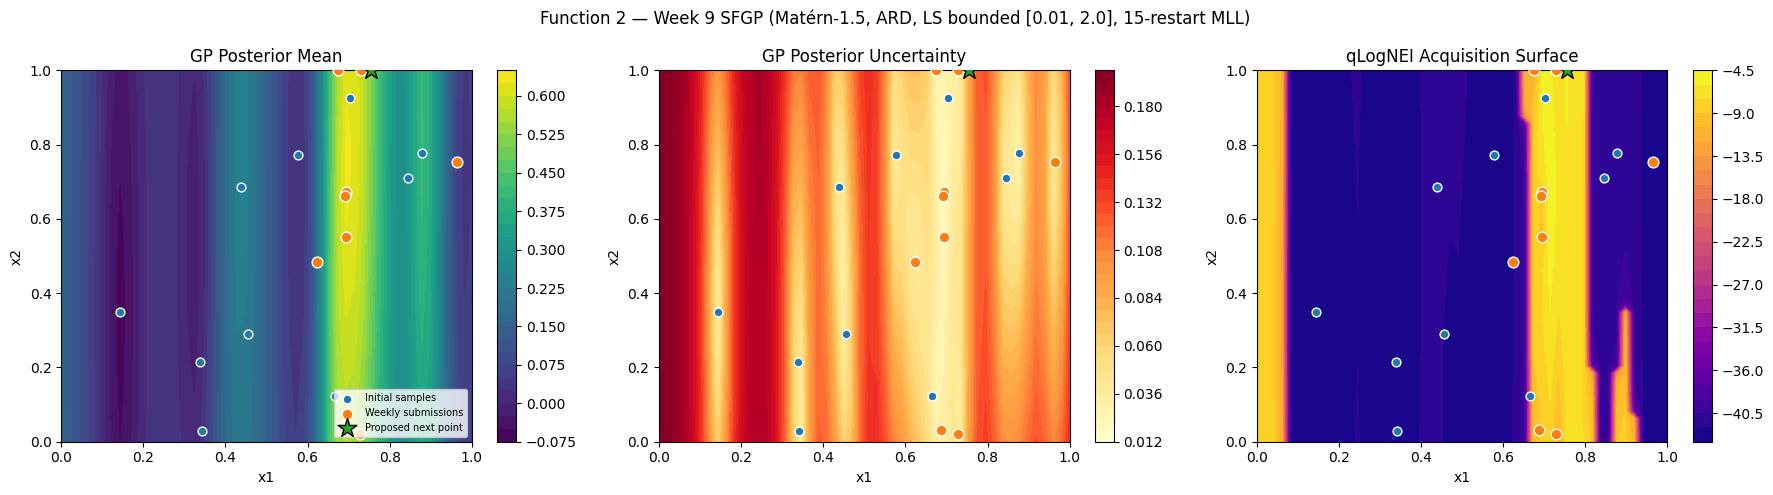

In [6]:
# ── Build 50×50 evaluation grid over [0, 1]² ──────────────────────────────────
n_grid = 50
x1_lin = np.linspace(0, 1, n_grid)
x2_lin = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_lin, x2_lin)
grid_np = np.column_stack([X1.ravel(), X2.ravel()])
grid_t  = torch.tensor(grid_np, dtype=torch.float64)

# ── GP posterior mean and std on grid ─────────────────────────────────────────
best_model.eval()
with torch.no_grad():
    posterior  = best_model.posterior(grid_t)
    mean_grid  = posterior.mean.numpy().reshape(n_grid, n_grid)
    std_grid   = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# ── qLogNEI acquisition surface on grid ───────────────────────────────────────
acqf_vals = []
batch_size = 500
for i in range(0, len(grid_np), batch_size):
    batch = grid_t[i:i + batch_size].unsqueeze(1)   # shape [B, 1, 2]
    with torch.no_grad():
        acqf_vals.append(acqf(batch).numpy())
acqf_grid = np.concatenate(acqf_vals).reshape(n_grid, n_grid)

# ── Three-panel figure with three-colour scheme ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, (data, title, cmap) in enumerate([
    (mean_grid, 'GP Posterior Mean', 'viridis'),
    (std_grid, 'GP Posterior Uncertainty', 'YlOrRd'),
    (acqf_grid, 'qLogNEI Acquisition Surface', 'plasma'),
]):
    ax = axes[ax_idx]
    c = ax.contourf(X1, X2, data, levels=30, cmap=cmap)

    # Initial samples (blue)
    ax.scatter(X_initial[:, 0], X_initial[:, 1], c='tab:blue', s=40,
               edgecolors='white', zorder=5,
               label='Initial samples' if ax_idx == 0 else None)

    # Weekly submissions (orange)
    ax.scatter(X_submissions[:, 0], X_submissions[:, 1], c='tab:orange', s=60,
               edgecolors='white', zorder=5,
               label='Weekly submissions' if ax_idx == 0 else None)

    # Proposed next point (green star)
    ax.scatter(x_new[0], x_new[1], c='tab:green', marker='*', s=200,
               edgecolors='black', zorder=6,
               label='Proposed next point' if ax_idx == 0 else None)

    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title)
    if ax_idx == 0:
        ax.legend(loc='lower right', fontsize=7)
    plt.colorbar(c, ax=ax)

plt.suptitle('Function 2 — Week 9 SFGP (Matérn-1.5, ARD, LS bounded [0.01, 2.0], 15-restart MLL)', fontsize=12)
plt.tight_layout()
plt.show()

### Step 7: Convergence Plot

Running maximum (best observed value) across all 19 observations. Blue dots for initial period, orange for weekly submissions. Vertical line separates initial samples from submissions.

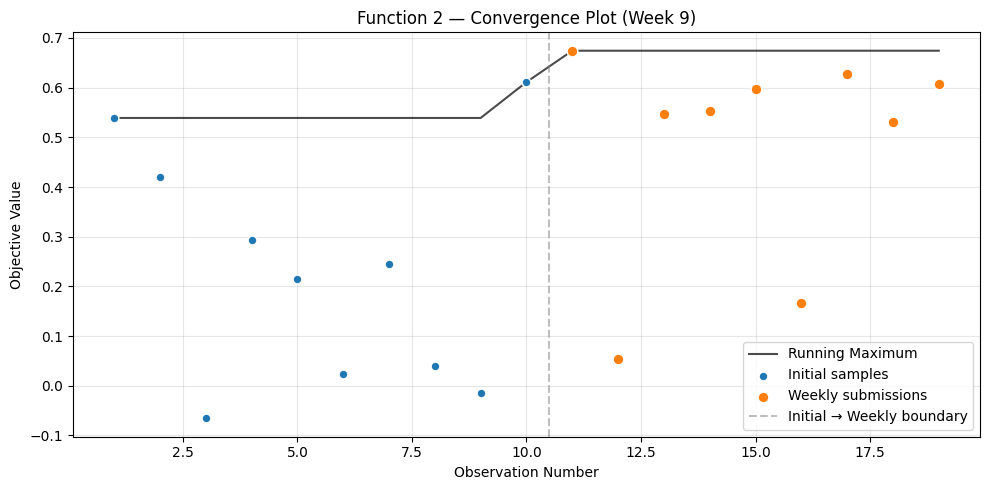

Best observed value: 0.674355
Achieved at observation: 11
Best after initial:     0.611205
Best after submissions: 0.674355
Submissions improved best: Yes ✓


In [7]:
# Running maximum (convergence) over all 19 observations
running_max = np.maximum.accumulate(y)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y) + 1), running_max, 'k-', linewidth=1.5, alpha=0.7, label='Running Maximum')

# Individual observations with two-colour scheme
plt.scatter(range(1, N_INITIAL + 1), y[:N_INITIAL],
            c='tab:blue', s=40, edgecolors='white', zorder=5, label='Initial samples')
plt.scatter(range(N_INITIAL + 1, N_TOTAL + 1), y[N_INITIAL:],
            c='tab:orange', s=60, edgecolors='white', zorder=5, label='Weekly submissions')

plt.axvline(x=N_INITIAL + 0.5, color='gray', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 — Convergence Plot (Week 9)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y.max():.6f}")
print(f"Achieved at observation: {y.argmax() + 1}")
best_initial = y[:N_INITIAL].max()
best_final = y.max()
print(f"Best after initial:     {best_initial:.6f}")
print(f"Best after submissions: {best_final:.6f}")
improved = best_final > best_initial
print(f"Submissions improved best: {'Yes ✓' if improved else 'No — initial best retained'}")

### Step 8: Format Submission Query

Format the **distance-based selected** point as `x1-x2` with 6 decimal places, clamped to `[0.0, 0.999999]`.  
This point was chosen from the q=4 batch as the candidate with posterior mean ≥ median that is farthest from all training data.

In [8]:
# Clamp proposed point to valid submission bounds [0.0, 0.999999]
x1_sub = max(0.0, min(0.999999, x_new[0]))
x2_sub = max(0.0, min(0.999999, x_new[1]))

# Verify no duplicate with existing observations
observed_queries = [f"{X[i,0]:.6f}-{X[i,1]:.6f}" for i in range(len(X))]
proposed_query = f"{x1_sub:.6f}-{x2_sub:.6f}"
is_duplicate = proposed_query in observed_queries

print("=" * 60)
print("WEEK 9 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate:   SFGP (Matérn-1.5, ARD=True, noise_lb={NOISE_LB})")
print(f"Acquisition: qLogNEI (q={Q}) → distance-based selection")
print(f"MLL restarts: {N_MLL_RESTARTS}")
print(f"LS bounds:    [{LS_LOWER}, {LS_UPPER}]")
print(f"Lengthscales: x1={lengthscales[0]:.4f}, x2={lengthscales[1]:.4f}")
print(f"Noise level:  {noise:.6f}")
print(f"Best observed y: {y.max():.6f}")
print(f"Proposed next:   [{x1_sub:.6f}, {x2_sub:.6f}]")
print(f"Duplicate check: {'⚠ DUPLICATE — resample needed' if is_duplicate else 'OK — unique point'}")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 60)

WEEK 9 SUBMISSION QUERY FOR FUNCTION 2
Surrogate:   SFGP (Matérn-1.5, ARD=True, noise_lb=0.001)
Acquisition: qLogNEI (q=4) → distance-based selection
MLL restarts: 15
LS bounds:    [0.01, 2.0]
Lengthscales: x1=0.0843, x2=2.0000
Noise level:  0.014052
Best observed y: 0.674355
Proposed next:   [0.755689, 0.999999]
Duplicate check: OK — unique point

>>> SUBMISSION: 0.755689-0.999999


---

## 6 · Performance Evaluation

### Cell 10: Convergence Metrics

Quantitative assessment of optimisation progress. Computes running best trajectory, per-submission improvement, and stalling detection (tail-only consecutive check).

In [9]:
# ── Convergence Metrics ────────────────────────────────────────────────────────
best_initial = y[:N_INITIAL].max()

# Best-value trajectory: running max after each submission
best_trajectory = np.array([y[:N_INITIAL + k + 1].max() for k in range(N_SUBMISSIONS)])

# Per-submission improvement delta
per_submission_delta = np.diff(np.concatenate([[best_initial], best_trajectory]))
new_best_flags = per_submission_delta > 0

# Consecutive no-improvement (tail-only: count backwards from most recent)
tail_no_improve = 0
for flag in reversed(new_best_flags):
    if not flag:
        tail_no_improve += 1
    else:
        break
consecutive_no_improvement = tail_no_improve

# Relative improvement
best_final = y.max()
improvement = best_final - best_initial

if abs(best_initial) < 1e-10:
    relative_improvement = 0.0 if improvement < 1e-10 else 1.0
else:
    relative_improvement = improvement / abs(best_initial)

# Stalling flag
stalling_flag = (consecutive_no_improvement >= STALLING_CONSECUTIVE_THRESHOLD or
                 relative_improvement < STALLING_RELATIVE_THRESHOLD)

# ── Summary Table ─────────────────────────────────────────────────────────────
print("=" * 60)
print("CONVERGENCE METRICS — Function 2, Week 9")
print("=" * 60)
print(f"  Best after initial samples: {best_initial:.6f}")
print(f"  Best after all submissions: {best_final:.6f}")
print(f"  Absolute improvement:       {improvement:.6f}")
print(f"  Relative improvement:       {relative_improvement:.4f} ({relative_improvement*100:.1f}%)")
print(f"  Submissions finding new best: {new_best_flags.sum()} / {N_SUBMISSIONS}")
print(f"  Trailing no-improvement streak: {consecutive_no_improvement}")
print(f"  Stalling flag: {'⚠ YES — STALLING' if stalling_flag else '✓ NO — healthy progress'}")
print()

# Per-submission detail
print(f"{'Sub':>4}  {'Best After':>12}  {'Delta':>10}  {'New Best?':>10}")
print("-" * 42)
for k in range(N_SUBMISSIONS):
    marker = "✓" if new_best_flags[k] else "—"
    print(f"{k+1:>4}  {best_trajectory[k]:>12.6f}  {per_submission_delta[k]:>10.6f}  {marker:>10}")

CONVERGENCE METRICS — Function 2, Week 9
  Best after initial samples: 0.611205
  Best after all submissions: 0.674355
  Absolute improvement:       0.063150
  Relative improvement:       0.1033 (10.3%)
  Submissions finding new best: 1 / 9
  Trailing no-improvement streak: 8
  Stalling flag: ⚠ YES — STALLING

 Sub    Best After       Delta   New Best?
------------------------------------------
   1      0.674355    0.063150           ✓
   2      0.674355    0.000000           —
   3      0.674355    0.000000           —
   4      0.674355    0.000000           —
   5      0.674355    0.000000           —
   6      0.674355    0.000000           —
   7      0.674355    0.000000           —
   8      0.674355    0.000000           —
   9      0.674355    0.000000           —


### Cell 11: Exploration Spread

Pairwise Euclidean distances between the 9 weekly submission points. For 2D inputs in [0,1]², uniform random points have mean pairwise distance ~0.52. Values significantly below this indicate clustering.

EXPLORATION SPREAD — Function 2, Week 9
  Number of submissions:        9
  Mean pairwise distance:       0.4496  (uniform 2D ≈ 0.52)
  Max nearest-neighbour dist:   0.2828
  Min nearest-neighbour dist:   0.0123  (tightest cluster)
  Clustering detected:          ✓ No


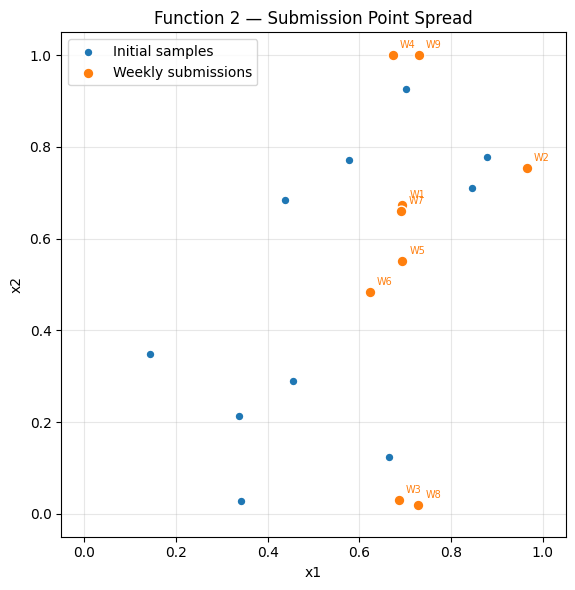

In [10]:
# ── Exploration Spread Metrics ─────────────────────────────────────────────────
dists = pdist(X_submissions)
mean_pairwise = dists.mean()

dist_matrix = squareform(dists)
np.fill_diagonal(dist_matrix, np.inf)
nn_dists = dist_matrix.min(axis=1)
max_nn_dist = nn_dists.max()
min_nn_dist = nn_dists.min()

print("=" * 60)
print("EXPLORATION SPREAD — Function 2, Week 9")
print("=" * 60)
print(f"  Number of submissions:        {N_SUBMISSIONS}")
print(f"  Mean pairwise distance:       {mean_pairwise:.4f}  (uniform 2D ≈ 0.52)")
print(f"  Max nearest-neighbour dist:   {max_nn_dist:.4f}")
print(f"  Min nearest-neighbour dist:   {min_nn_dist:.4f}  (tightest cluster)")

clustered = mean_pairwise < 0.52 * 0.7  # 30% below uniform expectation
print(f"  Clustering detected:          {'⚠ YES' if clustered else '✓ No'}")

# Scatter plot of submission points (2D only)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_initial[:, 0], X_initial[:, 1], c='tab:blue', s=40,
           edgecolors='white', zorder=5, label='Initial samples')
ax.scatter(X_submissions[:, 0], X_submissions[:, 1], c='tab:orange', s=60,
           edgecolors='white', zorder=5, label='Weekly submissions')

# Annotate submission order
for k in range(N_SUBMISSIONS):
    ax.annotate(f'W{k+1}', (X_submissions[k, 0], X_submissions[k, 1]),
                textcoords="offset points", xytext=(5, 5), fontsize=7, color='tab:orange')

ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Function 2 — Submission Point Spread')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Cell 12: LOO Surrogate Error

Leave-one-out cross-validation over the 9 weekly submission points. For each fold, retrain a fresh SFGP (Matérn-1.5, same configuration) on all data excluding one submission point, predict the held-out point, and compute the error in original output space.

**Note**: With only 9 folds, these metrics have limited statistical power but provide a useful diagnostic of surrogate prediction quality.

In [11]:
# ── Leave-One-Out Cross-Validation (9 folds over submissions) ─────────────────
loo_predictions = []
loo_actuals = []
loo_errors = []

print(f"{'Fold':>5}  {'Held-Out Idx':>13}  {'Actual':>10}  {'Predicted':>10}  {'Error':>10}")
print("-" * 55)

for fold in range(N_SUBMISSIONS):
    held_out_idx = N_INITIAL + fold  # Index in full dataset

    # Build LOO training set: all points except the held-out submission
    mask = np.ones(N_TOTAL, dtype=bool)
    mask[held_out_idx] = False
    X_loo = X[mask]
    y_loo = y[mask]

    X_loo_t = torch.tensor(X_loo, dtype=torch.float64)
    y_loo_t = torch.tensor(y_loo, dtype=torch.float64).unsqueeze(-1)

    # Retrain SFGP with same configuration (best of 5 restarts for speed)
    best_loo_loss = float('inf')
    best_loo_model = None

    for seed in range(5):
        torch.manual_seed(seed + 100)  # Different seed range from main fit

        covar_loo = ScaleKernel(
            MaternKernel(
                nu=1.5,
                ard_num_dims=N_DIMS,
                lengthscale_constraint=Interval(LS_LOWER, LS_UPPER)
            )
        )
        lik_loo = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))

        model_loo = SingleTaskGP(
            train_X=X_loo_t,
            train_Y=y_loo_t,
            covar_module=covar_loo,
            likelihood=lik_loo,
            input_transform=Normalize(d=N_DIMS)
        ).double()

        model_loo.covar_module.base_kernel.lengthscale = LS_INIT
        model_loo.likelihood.noise = NOISE_INIT
        model_loo.covar_module.outputscale = OUTPUTSCALE_INIT

        mll_loo = ExactMarginalLogLikelihood(lik_loo, model_loo)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit_gpytorch_mll(mll_loo)

        model_loo.eval()
        lik_loo.eval()
        with torch.no_grad():
            out_loo = model_loo(X_loo_t)
            loss_loo = -mll_loo(out_loo, model_loo.train_targets).item()

        if loss_loo < best_loo_loss:
            best_loo_loss = loss_loo
            best_loo_model = copy.deepcopy(model_loo)

    # Predict held-out point
    x_held = torch.tensor(X[held_out_idx:held_out_idx+1], dtype=torch.float64)
    best_loo_model.eval()
    with torch.no_grad():
        pred = best_loo_model.posterior(x_held).mean.item()

    actual = y[held_out_idx]
    error = abs(pred - actual)

    loo_predictions.append(pred)
    loo_actuals.append(actual)
    loo_errors.append(error)

    print(f"{fold+1:>5}  {held_out_idx:>13}  {actual:>10.6f}  {pred:>10.6f}  {error:>10.6f}")

# Summary statistics
loo_predictions = np.array(loo_predictions)
loo_actuals = np.array(loo_actuals)
loo_errors = np.array(loo_errors)

loo_mae = loo_errors.mean()
loo_rmse = np.sqrt((loo_errors**2).mean())

print(f"\n{'='*55}")
print(f"LOO SURROGATE ERROR — Function 2 (SFGP Matérn-1.5)")
print(f"{'='*55}")
print(f"  MAE:  {loo_mae:.6f}")
print(f"  RMSE: {loo_rmse:.6f}")
print(f"  Max error:  {loo_errors.max():.6f} (fold {loo_errors.argmax()+1})")
print(f"  Min error:  {loo_errors.min():.6f} (fold {loo_errors.argmin()+1})")
print(f"  Note: 9-fold LOO has limited statistical power")

 Fold   Held-Out Idx      Actual   Predicted       Error
-------------------------------------------------------
    1             10    0.674355    0.615672    0.058683
    2             11    0.054376    0.318247    0.263872
    3             12    0.546395    0.582300    0.035905
    4             13    0.552994    0.561234    0.008241
    5             14    0.597369    0.638377    0.041008
    6             15    0.166356    0.275450    0.109094
    7             16    0.628456    0.626464    0.001992
    8             17    0.530278    0.522227    0.008051
    9             18    0.606570    0.531370    0.075200

LOO SURROGATE ERROR — Function 2 (SFGP Matérn-1.5)
  MAE:  0.066894
  RMSE: 0.102054
  Max error:  0.263872 (fold 2)
  Min error:  0.001992 (fold 7)
  Note: 9-fold LOO has limited statistical power


### Cell 13: Interpretation & Strategy Recommendations

**Convergence Assessment**:  
Review the stalling flag above. If `stalling_flag = True`, the optimisation has plateaued — either the trailing no-improvement streak ≥ 3, or overall relative improvement < 5%. If healthy, the current strategy is effective.

**Exploration Spread**:  
For 2D inputs in [0,1]², uniform random points give mean pairwise distance ≈ 0.52. If the observed value is significantly below this (< 0.36), submissions are clustered and the acquisition function may be over-exploiting.

**LOO Surrogate Accuracy**:  
The LOO MAE and RMSE indicate how well the SFGP predicts unseen submission outcomes. High error relative to the output range suggests the surrogate is poorly calibrated in the submission region.

**If stalling, consider these strategy changes for Week 10**:
1. **Switch kernel to Matérn 2.5** — smoother extrapolation may help escape the current plateau
2. **Increase raw_samples from 512 to 2048** — broader acquisition search for candidates in unexplored regions
3. **Add random restart perturbation** — inject noise into acquisition restarts to escape local optima

**If not stalling**: Continue with the current SFGP Matérn-1.5 + qLogNEI (q=4) + distance-based selection strategy. Monitor whether the exploration-exploitation balance remains effective.